In [ ]:
import os
import zipfile
import random
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

ZIP_PATH = "/home/sanjitap/projects/personal/me5920/hw1/Agricultural_Image_Analytics.zip"  
EXTRACT_DIR = Path("./leaf_data")

# Unzip
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(EXTRACT_DIR)

# Collect image files (common extensions)
img_exts = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
image_paths = [p for p in EXTRACT_DIR.rglob("*") if p.suffix.lower() in img_exts]

print("Total images found:", len(image_paths))
print("Example:", image_paths[0] if image_paths else "No images found")

Total images found: 26
Example: leaf_data/Agricultural_Image_Analytics/4.JPG


Saved augmented images to: /home/sanjitap/projects/personal/me5920/hw1/augmented_100


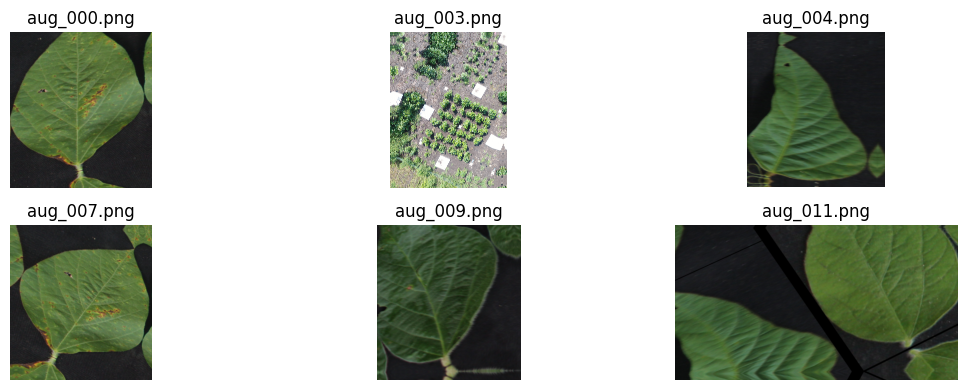

In [3]:
AUG_OUT = Path("./augmented_100")
AUG_OUT.mkdir(exist_ok=True)

def random_affine_and_warp(img_bgr, out_size=None):
    """
    img_bgr: HxWx3 uint8
    out_size: (W,H) if you want fixed output size
    """
    img = img_bgr.copy()
    H, W = img.shape[:2]

    # --- Random affine: rotate + scale + shift ---
    angle = random.uniform(-30, 30)        # degrees
    scale = random.uniform(0.85, 1.15)
    tx = random.uniform(-0.10*W, 0.10*W)   # shift x
    ty = random.uniform(-0.10*H, 0.10*H)   # shift y

    M = cv2.getRotationMatrix2D((W/2, H/2), angle, scale)
    M[0, 2] += tx
    M[1, 2] += ty

    affine = cv2.warpAffine(img, M, (W, H), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT)

    # --- Random perspective warp ---
    # source corners
    src = np.float32([[0,0],[W-1,0],[W-1,H-1],[0,H-1]])

    # perturb corners by a small fraction
    max_perturb = 0.08
    dst = src + np.float32([
        [random.uniform(-max_perturb, max_perturb)*W, random.uniform(-max_perturb, max_perturb)*H],
        [random.uniform(-max_perturb, max_perturb)*W, random.uniform(-max_perturb, max_perturb)*H],
        [random.uniform(-max_perturb, max_perturb)*W, random.uniform(-max_perturb, max_perturb)*H],
        [random.uniform(-max_perturb, max_perturb)*W, random.uniform(-max_perturb, max_perturb)*H],
    ])

    P = cv2.getPerspectiveTransform(src, dst)
    warped = cv2.warpPerspective(affine, P, (W, H), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT)

    if out_size is not None:
        warped = cv2.resize(warped, out_size, interpolation=cv2.INTER_AREA)
    return warped

# Generate 100 augmented images
random.seed(0)
np.random.seed(0)

N_AUG = 100
chosen = [random.choice(image_paths) for _ in range(N_AUG)]

for i, p in enumerate(chosen):
    img = cv2.imread(str(p))
    if img is None:
        continue
    aug = random_affine_and_warp(img)
    out_path = AUG_OUT / f"aug_{i:03d}.png"
    cv2.imwrite(str(out_path), aug)

print("Saved augmented images to:", AUG_OUT.resolve())
# Show a few augmented samples
sample_aug = sorted(AUG_OUT.glob("*.png"))[:6]
plt.figure(figsize=(12,4))
for i, p in enumerate(sample_aug):
    img = cv2.imread(str(p))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(2,3,i+1)
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.title(p.name)
plt.tight_layout()
plt.show()

In [4]:
PATCH_SIZE = 64
PATCHES_PER_IMAGE = 10   # adjust as needed (more patches = more compute)

def extract_random_patches(img_bgr, patch_size=64, num_patches=10):
    H, W = img_bgr.shape[:2]
    ps = patch_size
    if H < ps or W < ps:
        # resize small images up so we can take patches
        scale = max(ps/H, ps/W) + 1e-6
        img_bgr = cv2.resize(img_bgr, (int(W*scale), int(H*scale)), interpolation=cv2.INTER_CUBIC)
        H, W = img_bgr.shape[:2]

    patches = []
    for _ in range(num_patches):
        y = random.randint(0, H-ps)
        x = random.randint(0, W-ps)
        patch = img_bgr[y:y+ps, x:x+ps, :]
        patches.append(patch)
    return patches

# Collect patches
random.seed(0)
all_patches_bgr = []

for p in image_paths:
    img = cv2.imread(str(p))
    if img is None:
        continue
    pts = extract_random_patches(img, patch_size=PATCH_SIZE, num_patches=PATCHES_PER_IMAGE)
    all_patches_bgr.extend(pts)

print("Total patches:", len(all_patches_bgr), "Shape of one patch:", all_patches_bgr[0].shape)

patches = np.stack([cv2.cvtColor(x, cv2.COLOR_BGR2RGB) for x in all_patches_bgr]).astype(np.float32) / 255.0
print("patches array:", patches.shape, patches.dtype)  # (N, 64, 64, 3)

Total patches: 130 Shape of one patch: (64, 64, 3)
patches array: (130, 64, 64, 3) float32


whitened_patches: (130, 64, 64, 3) float32
Whitened min/max: -0.84283066 1.3400049


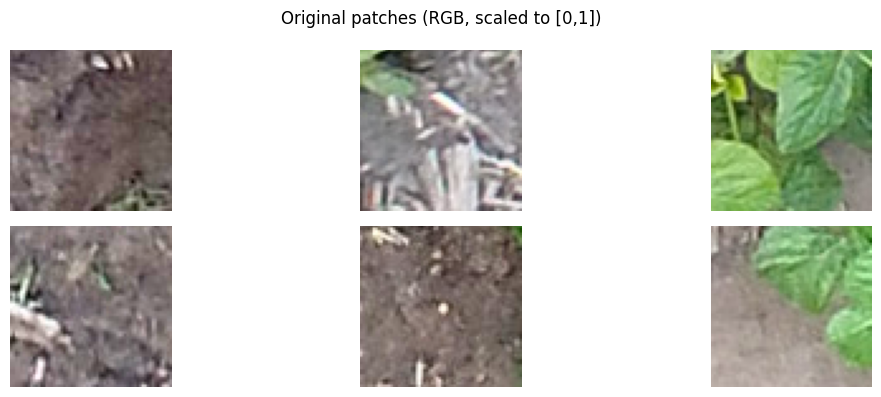

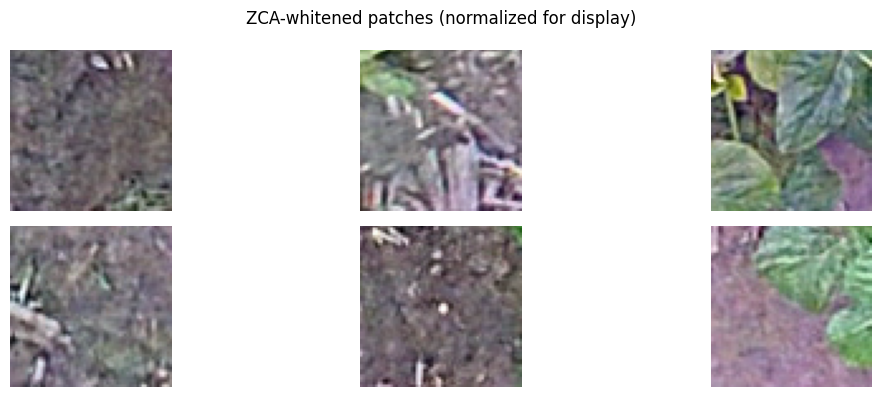

In [5]:
def zca_whiten(patches_nhwc, eps=1e-5):
    """
    patches_nhwc: (N, H, W, C) float32 in [0,1]
    returns: whitened patches (N,H,W,C) and params
    """
    N, H, W, C = patches_nhwc.shape
    X = patches_nhwc.reshape(N, -1)  # (N, D)
    
    # zero-center
    mean = X.mean(axis=0, keepdims=True)
    Xc = X - mean

    # covariance
    cov = (Xc.T @ Xc) / N  # (D,D)

    # SVD
    U, S, _ = np.linalg.svd(cov, full_matrices=False)

    # ZCA matrix
    zca_mat = U @ np.diag(1.0 / np.sqrt(S + eps)) @ U.T  # (D,D)

    Xw = Xc @ zca_mat
    patches_w = Xw.reshape(N, H, W, C)

    params = {"mean": mean, "zca_mat": zca_mat, "eps": eps}
    return patches_w, params

whitened_patches, zca_params = zca_whiten(patches, eps=1e-5)
print("whitened_patches:", whitened_patches.shape, whitened_patches.dtype)
print("Whitened min/max:", whitened_patches.min(), whitened_patches.max())

def show_patch_grid(patches_nhwc, title, n=6):
    plt.figure(figsize=(12,4))
    for i in range(n):
        img = patches_nhwc[i]
        # normalize per image for display
        disp = img - img.min()
        disp = disp / (disp.max() + 1e-8)
        plt.subplot(2,3,i+1)
        plt.imshow(disp)
        plt.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_patch_grid(patches, "Original patches (RGB, scaled to [0,1])", n=6)
show_patch_grid(whitened_patches, "ZCA-whitened patches (normalized for display)", n=6)

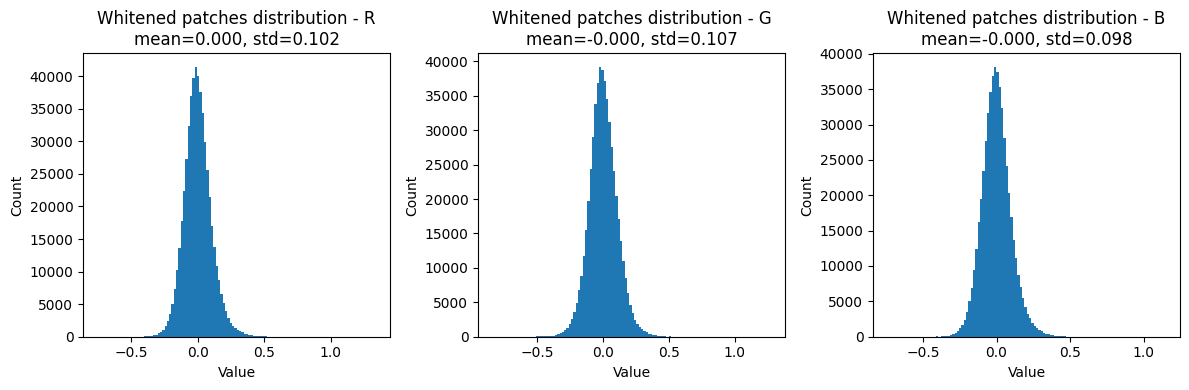

In [7]:
def channel_distribution(patches_nhwc, title, bins=100):
    """
    patches_nhwc: (N,H,W,C)
    """
    C = patches_nhwc.shape[-1]
    channel_names = ["R","G","B"] if C == 3 else [f"C{i}" for i in range(C)]

    plt.figure(figsize=(12,4))
    for c in range(C):
        vals = patches_nhwc[..., c].ravel()
        plt.subplot(1, C, c+1)
        plt.hist(vals, bins=bins)
        plt.title(f"{title} - {channel_names[c]}\nmean={vals.mean():.3f}, std={vals.std():.3f}")
        plt.xlabel("Value")
        plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

channel_distribution(whitened_patches, "Whitened patches distribution", bins=120)

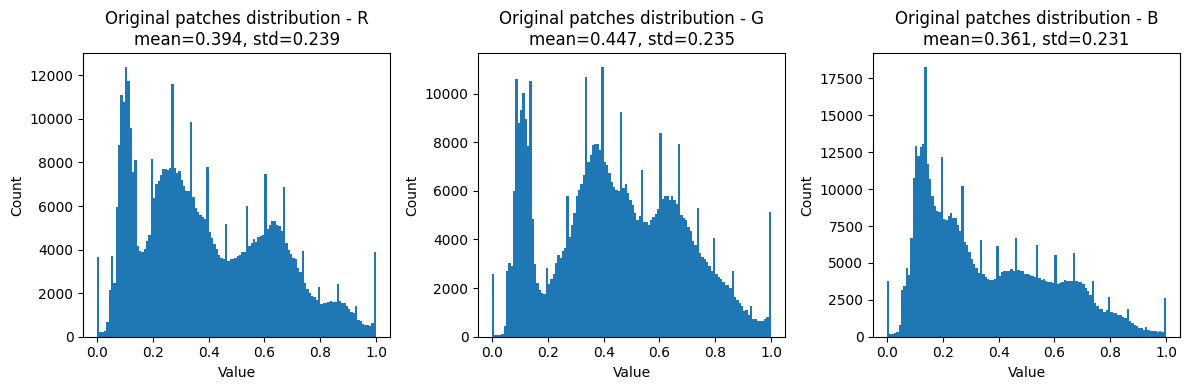

In [8]:
channel_distribution(patches, "Original patches distribution", bins=120)

# Discussion
Original patches: pixel values are bounded (roughly 0 to 1 after scaling), and the distribution depends on leaf color/lighting (often skewed toward greens).

ZCA-whitened patches: values are zero-centered and can be negative; distributions typically look more symmetric, with reduced correlation between features.

3.2 Image Segmentation

In [9]:
import os, zipfile, random
from pathlib import Path

import cv2
import numpy as np
from scipy.signal import find_peaks

In [10]:
ZIP_PATH = "/home/sanjitap/projects/personal/me5920/hw1/Agricultural_Image_Analytics.zip"   # change if your zip name differs

EXTRACT_DIR = Path("./soybean_seg_data")
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(EXTRACT_DIR)

img_exts = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
image_paths = [p for p in EXTRACT_DIR.rglob("*") if p.suffix.lower() in img_exts]
print("Found images:", len(image_paths))

Found images: 26


In [11]:
def green_mask(img_bgr):
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

    # Typical green range; adjust if needed
    lower = np.array([25, 40, 40])   # H,S,V
    upper = np.array([95, 255, 255])

    mask = cv2.inRange(hsv, lower, upper)

    # Clean up
    mask = cv2.medianBlur(mask, 5)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((5,5), np.uint8), iterations=1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((9,9), np.uint8), iterations=2)

    return mask  # 0/255

In [12]:
def find_cut_lines(proj, n_cells=6, smooth_ksize=61):
    proj = proj.astype(np.float32)
    k = smooth_ksize if smooth_ksize % 2 == 1 else smooth_ksize + 1
    proj_smooth = cv2.GaussianBlur(proj.reshape(1, -1), (k, 1), 0).ravel()

    inv = proj_smooth.max() - proj_smooth  # valleys become peaks

    dist = max(10, len(proj)//(n_cells*2))
    peaks, props = find_peaks(inv, distance=dist, prominence=np.percentile(inv, 80)*0.05)

    need = n_cells - 1
    if len(peaks) >= need:
        prominences = props.get("prominences", np.ones_like(peaks))
        top_idx = np.argsort(prominences)[-need:]
        internal = np.sort(peaks[top_idx])
    else:
        internal = np.linspace(0, len(proj)-1, n_cells+1)[1:-1].astype(int)

    cuts = np.concatenate([[0], internal, [len(proj)]])
    cuts = np.clip(cuts, 0, len(proj))
    cuts = np.unique(cuts)

    if len(cuts) != n_cells + 1:
        cuts = np.linspace(0, len(proj), n_cells+1).astype(int)

    return cuts

In [55]:
def largest_component_bbox(mask_cell, min_area=800):
    num, labels, stats, _ = cv2.connectedComponentsWithStats(
        (mask_cell > 0).astype(np.uint8), connectivity=8
    )

    if num <= 1:
        return None

    areas = stats[1:, cv2.CC_STAT_AREA]
    best_idx = 1 + np.argmax(areas)
    area = stats[best_idx, cv2.CC_STAT_AREA]

    if area < min_area:
        return None

    x = stats[best_idx, cv2.CC_STAT_LEFT]
    y = stats[best_idx, cv2.CC_STAT_TOP]
    w = stats[best_idx, cv2.CC_STAT_WIDTH]
    h = stats[best_idx, cv2.CC_STAT_HEIGHT]

    if w > 1.8*h or h > 1.8*w:
        return None
    # after computing w, h



    # if w*h > 30000:
    #     return None

    return (x, y, x+w, y+h)

In [56]:
OUT_DIR = Path("./soybean_seg_outputs_like_example")
OUT_DIR.mkdir(exist_ok=True)

def segment_soybean_36(img_path, n_cells=6):
    img_bgr = cv2.imread(str(img_path))
    if img_bgr is None:
        print("Cannot read:", img_path)
        return

    # Resize for stable behavior
    H, W = img_bgr.shape[:2]
    if W > 1400:
        scale = 1400 / W
        img_bgr = cv2.resize(img_bgr, (int(W*scale), int(H*scale)), interpolation=cv2.INTER_AREA)

    H, W = img_bgr.shape[:2]
    gmask = green_mask(img_bgr)

    
    proj_y = (gmask > 0).sum(axis=1).astype(np.float32)
    proj_y_smooth = cv2.GaussianBlur(proj_y.reshape(-1, 1), (1, 51), 0).ravel()

    thresh = np.percentile(proj_y_smooth, 60)
    rows = np.where(proj_y_smooth > thresh)[0]

    if len(rows) < 20:
        y_min, y_max = 0, gmask.shape[0]
    else:
        y_min, y_max = rows.min(), rows.max()

    pad = int(0.10 * gmask.shape[0])   # 10% height
    y_min = max(0, y_min - pad)
    y_max = min(gmask.shape[0], y_max + pad)

    roi_mask = gmask[y_min:y_max, :]

        # Projections computed ONLY on ROI
    col_proj = (roi_mask > 0).sum(axis=0)
    row_proj = (roi_mask > 0).sum(axis=1)

    x_cuts = find_cut_lines(col_proj, n_cells=n_cells)
    y_cuts_roi = find_cut_lines(row_proj, n_cells=n_cells)

    # Convert ROI y-cuts back to full-image coordinates
    y_cuts = y_cuts_roi + y_min

    stem = img_path.stem
    img_out_dir = OUT_DIR / stem
    crops_dir = img_out_dir / "crops_36"
    img_out_dir.mkdir(parents=True, exist_ok=True)
    crops_dir.mkdir(exist_ok=True)

    annotated = img_bgr.copy()
    idx = 1

    for r in range(n_cells):
        y0, y1 = int(y_cuts[r]), int(y_cuts[r+1])
        for c in range(n_cells):
            x0, x1 = int(x_cuts[c]), int(x_cuts[c+1])

            cell_mask = gmask[y0:y1, x0:x1]

            # (CHANGE #3) increase min_area to suppress weeds/noise
            bbox = largest_component_bbox(cell_mask, min_area=350)

          
            if bbox is None:
                idx += 1
                continue

            cx0, cy0, cx1, cy1 = bbox
            pad = 4
            bx0 = max(x0 + cx0 - pad, 0)
            by0 = max(y0 + cy0 - pad, 0)
            bx1 = min(x0 + cx1 + pad, W)
            by1 = min(y0 + cy1 + pad, H)

            # save crop
            crop = img_bgr[by0:by1, bx0:bx1]
            cv2.imwrite(str(crops_dir / f"subplot_{idx:02d}.png"), crop)

            # draw bbox + label
            cv2.rectangle(annotated, (bx0, by0), (bx1, by1), (0,0,255), 2)
            cv2.putText(annotated, str(idx), (bx0+4, by0+18),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.65, (0,0,255), 2, cv2.LINE_AA)

            idx += 1

    out_annot = img_out_dir / f"{stem}_annotated.png"
    cv2.imwrite(str(out_annot), annotated)
    print("✅ Saved:", out_annot)

# Run on all images
for p in image_paths:
    segment_soybean_36(p)

✅ Saved: soybean_seg_outputs_like_example/4/4_annotated.png
✅ Saved: soybean_seg_outputs_like_example/5/5_annotated.png
✅ Saved: soybean_seg_outputs_like_example/2/2_annotated.png
✅ Saved: soybean_seg_outputs_like_example/3/3_annotated.png
✅ Saved: soybean_seg_outputs_like_example/1/1_annotated.png
✅ Saved: soybean_seg_outputs_like_example/I8/I8_annotated.png
✅ Saved: soybean_seg_outputs_like_example/I1/I1_annotated.png
✅ Saved: soybean_seg_outputs_like_example/I2/I2_annotated.png
✅ Saved: soybean_seg_outputs_like_example/I3/I3_annotated.png
✅ Saved: soybean_seg_outputs_like_example/I7/I7_annotated.png
✅ Saved: soybean_seg_outputs_like_example/I6/I6_annotated.png
✅ Saved: soybean_seg_outputs_like_example/I4/I4_annotated.png
✅ Saved: soybean_seg_outputs_like_example/I5/I5_annotated.png
Cannot read: soybean_seg_data/__MACOSX/Agricultural_Image_Analytics/._4.JPG
Cannot read: soybean_seg_data/__MACOSX/Agricultural_Image_Analytics/._5.JPG
Cannot read: soybean_seg_data/__MACOSX/Agricultural_

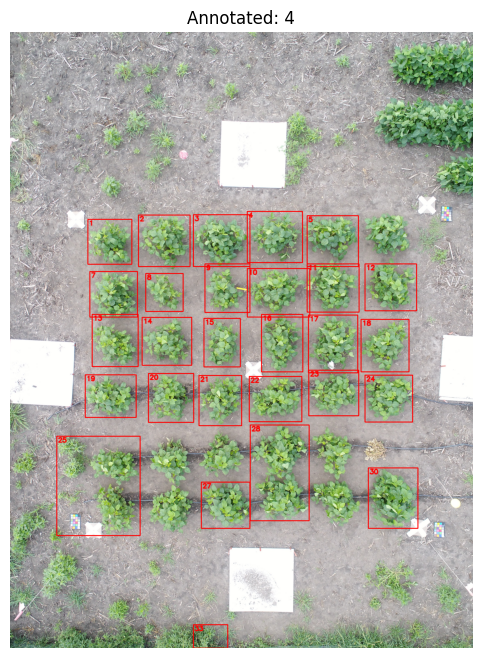

In [57]:
import matplotlib.pyplot as plt

folders = [d for d in OUT_DIR.iterdir() if d.is_dir()]
if folders:
    ann = folders[0] / f"{folders[0].name}_annotated.png"
    img = cv2.imread(str(ann))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(8,8))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Annotated: {folders[0].name}")
    plt.show()